In [1]:
import json
import pandas as pd
from IPython.display import HTML, display
import matplotlib as plt



In [2]:
data=[]
with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics.jsonl")as f:
    for line in f:
        data = json.loads(line)
        


KeyboardInterrupt: 

In [3]:
print(type(data))
data

<class 'dict'>


{'main_category': 'Camera & Photo',
 'title': '4MP Full Time Color Night Vision POE IP Camera, OEM DS-2CD2347G1-LU 4mm Lens, 2688×1520@30fps,Built-in MIC, 24/7 Colorful Imaging, MicroSD Recording, Outdoor Turret Network Security Camera with IP67',
 'average_rating': 4.1,
 'rating_number': 10,
 'features': ['【 24/7 Full Time Color】---- 4MP OEM full time color IP Camera & 24 hours Full-color Night Vision & WIDE VIEWING ANGLE: 4 Megapixel Super HD dome camera, 1/1.8" Progressive Scan CMOS, Max. 2688 × 1520 @30fps Super smooth quality, Full time color image even at night, up to 94˚ wide viewing angle, capture more clearer sharper and colorful images and video, 0.0014 Lux @ (F1.0, AGC ON), 0 Lux with Light',
  '【Built-in mic, H-2-6-5+, Micro SD】---- Built-in Mic for one way audio recording. Adopting Smart H-2-6-5+ reduces bit rate and storage requirements by up to 70% when compared to standard H-2-6-5 video compression. Built-in Micro SD/SDHC/SDXC slot, up to 128 GB(SD Card not included, ca

In [4]:
for i in range(len(data)//100):
    print(i ,":",data[i]['title'], "\n")
    

In [5]:
display(HTML('<div><h1>Explore Distribution By categories</h1></div>'))

In [6]:
import json

rows = []

with open(
    "C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics.jsonl",
    encoding="utf-8"
) as f:
    for i, line in enumerate(f):
        rows.append(json.loads(line))

        if i == 999:
            break

df = pd.DataFrame(rows)
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{'Date First Available': 'August 2, 2014', 'Ma...",B00MCW7G9M,None,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SIIG,"[Electronics, Television & Video, Accessories,...",{'Product Dimensions': '0.83 x 4.17 x 2.05 inc...,B00YT6XQSE,None,NaN,NaN
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'AL 2Sides Video', 'url': 'https://...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Digi-Tatoo', 'Color': 'Fresh Marble...",B07SM135LS,None,NaN,NaN
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{'Date First Available': 'May 29, 2020', 'Manu...",B089CNGZCW,None,NaN,NaN
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Verizon,"[Electronics, Computers & Accessories, Compute...",{'Product Dimensions': '11.6 x 6.9 x 3.1 inche...,B004E2Z88O,None,NaN,NaN


In [7]:
def filter_data(data: dict) -> bool:  # type: ignore
    """Return True if the item should be filtered out (Date First Available year < 2022)."""
    date_str = data.get('details', {}).get('Date First Available')
    if not date_str:
        # no date available — caller will handle by writing to the no-date file
        raise ValueError('no date')
    import re
    years = re.findall(r'(\d{4})', date_str)
    if not years:
        raise ValueError('no year found')
    year = int(years[-1])
    return year < 2022


In [8]:
with open(
    "C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics.jsonl",
    'r', encoding='utf-8') as fp:
    with open(
        "C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23.jsonl",
        'a', encoding='utf-8') as fp_out:
        with open(
            "C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_no_date.jsonl",
            'a', encoding='utf-8') as fp_out_no_dates:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write('\n')
                        fp_out.flush()
                except Exception:
                    json.dump(data, fp_out_no_dates)
                    fp_out_no_dates.write('\n')
                    fp_out_no_dates.flush()
                i += 1


KeyboardInterrupt: 

In [9]:
display(HTML('<div><h2>Split The Data Have main Categeory And dont Have main categeory</h2></div>'))

In [10]:
def filter_categeory(data:dict) -> bool:
    filter=False
    if data['main_category']==None:
        filter=True
        
    return filter
    

In [28]:
with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23.jsonl",'r') as fp:
    with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory.jsonl",'a',encoding='utf-8') as fp_out:
        with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_wiyh_no_categeory.jsonl",'a',encoding='utf-8')as fp_out_no_categeory:
            for line in fp:
                data=json.loads(line.strip())
                if not filter_categeory(data):
                    json.dump(data,fp_out) # type: ignore
                    fp_out.write('\n')
                    fp_out.flush()
                else:
                    json.dump(data,fp_out_no_categeory)
                    fp_out_no_categeory.write('\n')
                    fp_out_no_categeory.flush()

In [26]:

display(HTML('<div><h2>Explore Distribution By categeory</h2></div>'))

In [11]:
import os

file = r"C:\Users\jaysi\Desktop\Desktop\Ai-engineering\data\meta_Electronics_2022_23_with_categeory.jsonl"

print(os.path.getsize(file)/(1024*1024), "MB")

475.6667881011963 MB


In [12]:
df=pd.read_json("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory.jsonl",lines=True)
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,Amazon Home,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,50,[PROFESSIONAL STICKER SHOP.There are 50 differ...,"[Features:, - Clear picture and exquisite prin...",3.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Watch Before Buying! Huge Waterpro...,Affoto,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Affoto', 'Color': 'Outer Space', 'S...",B0BPLX8B2K,NaN,NaN,NaN
1,Computers,"Gateway 15.6"" FHD Ultra Slim Budget Notebook, ...",4.1,15,"[【Processor】4 Core, 4 Threads, 4MB Cache, up t...","[Processor:, Intel® Pentium® Silver N5030 Proc...",189.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Watch before you order ', 'url': '...",Gateway,"[Electronics, Computers & Accessories, Compute...",{'Standing screen display size': '15.6 Inches'...,B0BYBG1PPD,NaN,NaN,NaN
2,Cell Phones & Accessories,May Chen Compatible with MacBook Pro 16 inch C...,4.5,649,[【 COMPATIBLE WITH 】 Designed to Fits Perfectl...,[May Chen High Quality Plastic Hard Shell Case...,26.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'MOSISO Plastic Hard Shell Compati...,May Chen,"[Electronics, Computers & Accessories, Laptop ...","{'Standing screen display size': '16 Inches', ...",B0822SL7JX,NaN,NaN,NaN
3,All Electronics,"LENTION USB C Docking Station, 10 Gbps USB C&U...",4.4,16,[10-in-1 Docking Station - CB-D65 laptop docki...,[],89.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'LENTION D65 Upgrade Docking Statio...,LENTION,"[Electronics, Computers & Accessories, Laptop ...",{'Package Dimensions': '9.17 x 4.33 x 1.54 inc...,B0BKS1K986,NaN,NaN,NaN
4,All Electronics,1X (No Bluetooth) Eaglewireless Replacement To...,3.0,4,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Eaglewireless,[],{'Package Dimensions': '5.2 x 2.13 x 0.91 inch...,B09MY246CC,NaN,NaN,NaN


<Axes: xlabel='main_category'>

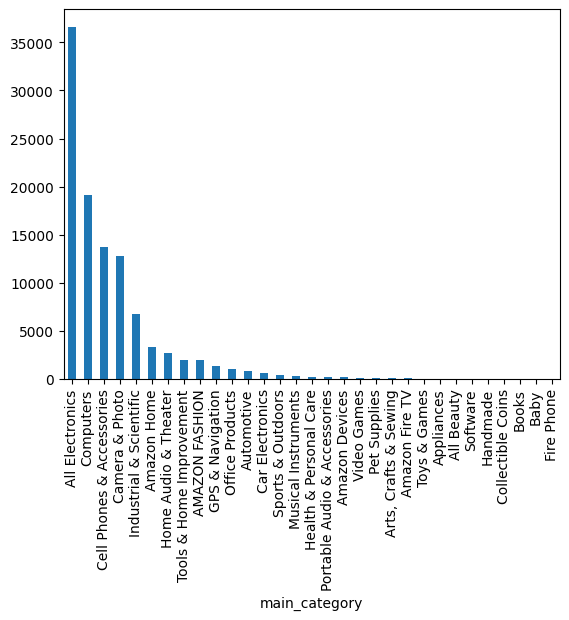

In [13]:
df['main_category'].value_counts().plot(kind='bar')

In [14]:
df_ratings_100=df[df['rating_number']>100]


<Axes: xlabel='main_category'>

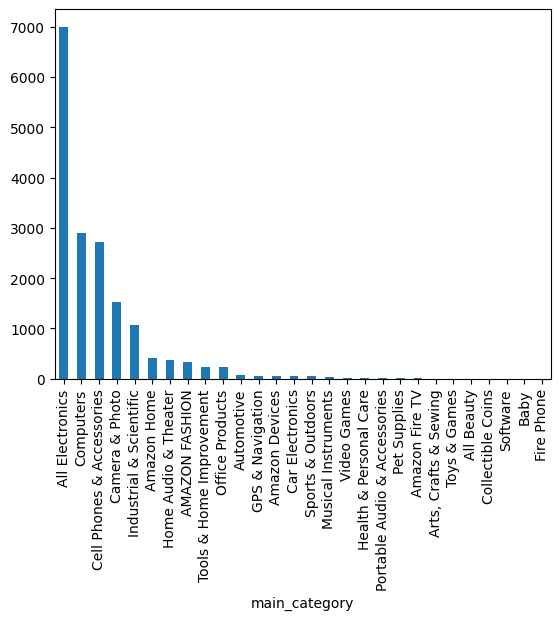

In [15]:
df_ratings_100['main_category'].value_counts().plot(kind='bar')

In [16]:
len(df_ratings_100)

17162

In [17]:
display(HTML('<div><h1>Explore Distribution of Ratings</h1></div>'))

<Axes: ylabel='Frequency'>

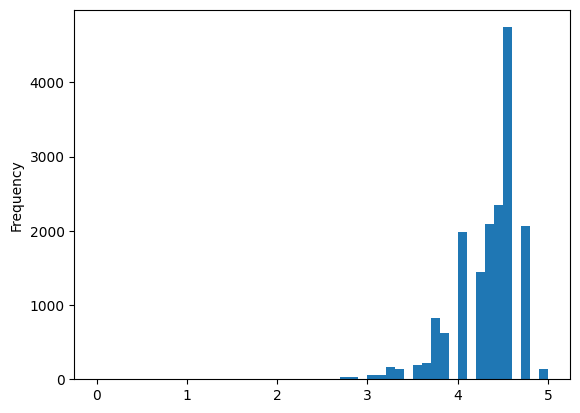

In [18]:
df_ratings_100['average_rating'].plot(kind='hist',bins=50 ,range=(0,5))

In [19]:
df_sample_2000=df_ratings_100.sample(n=2000,random_state=20)
df_sample_2000.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
56608,Industrial & Scientific,"RAVODOI USB C Cable, [2Pack/3.3ft+6.6ft] USB T...",4.4,119,[【Fast Charging Cord】These USB C cables provid...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Type-C Charger Cable ', 'url': 'ht...",RAVODOI,"[Electronics, Computers & Accessories, Compute...","{'Brand': 'RAVODOI', 'Connector Type': 'USB Ty...",B09R4Y2HKY,NaN,NaN,NaN
6301,All Electronics,"SNESH-2 Pack USB-C Female to USB Male Adapter,...",4.5,352,[🔹(Light & compact) Easy to carry and light we...,[],4.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'USB Male & Female Adapter', 'url':...",SNESH,"[Electronics, Computers & Accessories, Compute...",{'Package Dimensions': '3.54 x 2.4 x 0.35 inch...,B09JV5FM2S,NaN,NaN,NaN
78533,All Electronics,USB C Docking Station Dual Monitor for MacBook...,3.9,1193,[【18-in-1Docking Station】With USB C Docking St...,[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],ZMUIPNG,"[Electronics, Computers & Accessories, Laptop ...","{'Product Dimensions': '3.94""L x 1.18""W x 3.94...",B09SFN9NRX,NaN,NaN,NaN
75874,Camera & Photo,[2023 Upgraded] Telescopes for Adults Astronom...,4.1,219,[🎁【2023 All New Experience】The newly upgraded ...,[],169.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Good picture quality', 'url': 'htt...",HUTACT,"[Electronics, Camera & Photo, Binoculars & Sco...","{'Product Dimensions': '32.5""D x 5.5""W x 9.7""H...",B09TP3SZ7C,NaN,NaN,NaN
78895,AMAZON FASHION,"Laptop Bag 15.6 Inch, Laptop Briefcase Messeng...",4.5,222,"[Leather,Mesh, Imported, Multi-pockets and Lar...",[],24.95,[{'thumb': 'https://m.media-amazon.com/images/...,[],KPIQIU,"[Electronics, Computers & Accessories, Laptop ...",{'Product Dimensions': '16 x 2 x 12 inches; 1....,B0B5H7T7XZ,NaN,NaN,NaN


<Axes: ylabel='Frequency'>

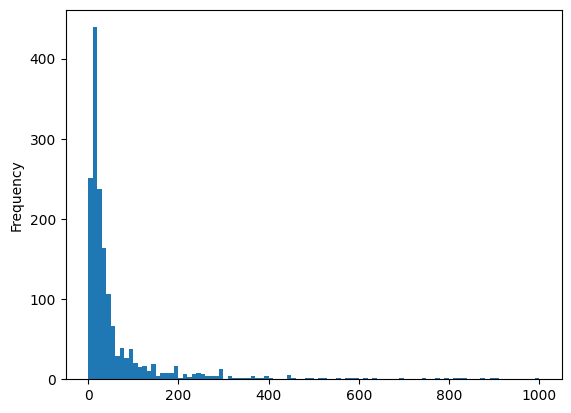

In [20]:
df_sample_2000['price'].plot(kind='hist',bins=100,range=(0,1000))

In [40]:
df_ratings_100.to_json("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100.jsonl",orient='records',lines=True)

In [41]:
df_sample_2000.to_json("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100_sample_2000.jsonl",orient='records',lines=True)

<Axes: ylabel='Frequency'>

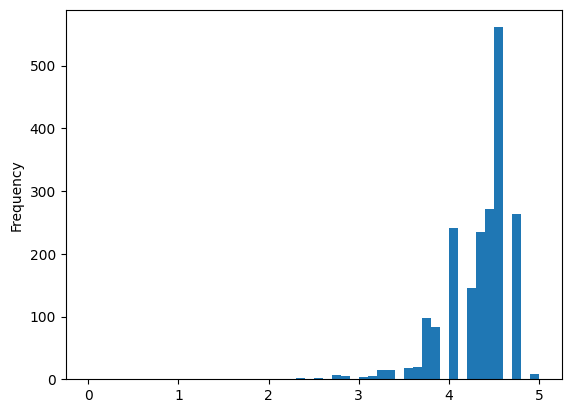

In [21]:
df_sample_2000['average_rating'].plot(kind='hist',bins=50,range=(0,5))

In [22]:
## Extracting rating That match sample data

In [23]:
df_ratings_100=pd.read_json("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100.jsonl",lines=True)
df_sample_2000=pd.read_json("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100_sample_2000.jsonl",lines=True)

In [ ]:
with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\Electronics.jsonl",'r')as fp:
    with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100.jsonl",'a') as fp_out:
        id_list=set(df_ratings_100['parent_asin'].values)
        i=0
        for line in fp:
            data=json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data,fp_out)
                fp_out.write("\n")
                fp_out.flush()
            i+=1
            if i%100000==0:
                print(f"prossed {i} lines")
        

In [28]:
with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100.jsonl",'r')as fp:
    with open("C:\\Users\\jaysi\\Desktop\\Desktop\\Ai-engineering\\data\\meta_Electronics_2022_23_with_categeory_rating_100_sample_2000.jsonl",'a') as fp_out:
        id_list=set(df_sample_2000['parent_asin'].values)
        i=0
        for lines in fp:
            data=json.loads(line.strip())
            if data['parent_asin'] in id_list:
                json.dump(data,fp_out)
                fp_out.write("\n")
                fp_out.flush()
            i+=1
            if i%100000==0:
                print(f"Prossed lines {i}")
        

Prossed lines 100000
Prossed lines 200000
Prossed lines 300000
Prossed lines 400000
Prossed lines 500000
Prossed lines 600000
Prossed lines 700000
Prossed lines 800000
Prossed lines 900000
Prossed lines 1000000
Prossed lines 1100000
Prossed lines 1200000
Prossed lines 1300000
Prossed lines 1400000
Prossed lines 1500000
Prossed lines 1600000
Prossed lines 1700000


## Ok